In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from src.data_reading import parse_galaxy_data
from src.data_treatment_tools import add_radian_columns, new_CoM_procedure 
from src.tools import equatorial_to_cartesian
import matplotlib as mpl

In [2]:
mpl.rcParams['font.size'] = 12  # Taille générale
mpl.rcParams['axes.titlesize'] = 16  # Taille des titres des graphiques
mpl.rcParams['axes.labelsize'] = 14  # Taille des labels des axes
mpl.rcParams['xtick.labelsize'] = 12  # Taille des étiquettes de l'axe x
mpl.rcParams['ytick.labelsize'] = 12  # Taille des étiquettes de l'axe y
mpl.rcParams['legend.fontsize'] = 12  # Taille de la légende
mpl.rcParams['figure.titlesize'] = 18  # Taille du titre de la figure

In [3]:
file_path = 'data/data_CoM_CenA_M83_0.64_lg_filtre_distance.csv'
galaxy_df = pd.read_csv(file_path)
add_radian_columns(galaxy_df)

In [4]:
galaxy1="NGC5128_CenA"
galaxy2="NGC5236_M83"
r=0.64
CoM_Name="CoM_CenA_M83_0.64"
row_name=CoM_Name
# new_CoM_procedure(galaxy_df,galaxy1,galaxy2,r,row_name=CoM_Name,grid_incertainty=True)
# print(galaxy_df.columns)

In [5]:
G = 4.3009e-9  

# Mass calculation

In [6]:
### cuts
velocity_max = 700
velocity_min = -700

distance_max = 1


### Virial Mass

In [7]:
def Dist3D(RA1,Dec1,Dist1,RA2,Dec2,Dist2):
    vec1=equatorial_to_cartesian(Dist1,RA1,Dec1)
    vec2=equatorial_to_cartesian(Dist2,RA2,Dec2)
    return np.linalg.norm(vec1-vec2)

def projected_distance(RA_series,Dec_series,Dist_series):
    RA = np.array(RA_series)
    Dec = np.array(Dec_series)
    Dist = np.array(Dist_series)
    if len(RA) != len(Dec):
        raise ValueError("Mismatched array lengths.")
    N=len(RA)
    sum_inversed_projected_distance = 0
    count=0
    for i in range(0,N):
        for j in range(i+1,N):
            Rij = Dist3D(RA[i],Dec[i],Dist[i],RA[j],Dec[j],Dist[j])# np.arccos(np.sin(Dec[i])*np.sin(Dec[j])+np.cos(Dec[i])*np.cos(Dec[j])*np.cos(RA[i]-RA[j]))*Dist
            sum_inversed_projected_distance += 1/Rij
            count +=1
    print(count)
    return count/sum_inversed_projected_distance

In [8]:
def Viriel_Mass(df,velocity, galaxy_excluded,row_name="CoM_CenA_M83_0.64",distance_max=1):
    G = 4.3009e-9  
    mask = (
    (~df['Name'].str.startswith('CoM_')) & 
    (~df['Name'].isin(galaxy_excluded))  &
    (df[velocity+"_"+row_name] >= velocity_min)  &
    (df[velocity+"_"+row_name] <= velocity_max)   &
    (df["dis_center_"+row_name]<= distance_max)
    )
    R_g=projected_distance(RA_series=df[mask]["RA_radians"],  Dec_series=df[mask]["Dec_radians"],  Dist_series= df[mask]["Dis"])
    v = df[mask][velocity + "_" + row_name]
    sigma_v = (v**2).mean() - v.mean()**2
    return 3*(sigma_v*R_g/G)

In [9]:
M_minor= Viriel_Mass(galaxy_df,velocity="minor_infall_velocity",galaxy_excluded=[galaxy1,galaxy2],distance_max=1)
M_major= Viriel_Mass(galaxy_df,velocity="major_infall_velocity",galaxy_excluded=[galaxy1,galaxy2],distance_max=1)
print(f"The Virial Mass according to the minor infall model with a bound system of {distance_max} Mpc is: {M_minor:.2e} M_⊙")
print(f"The Virial Mass according to the major infall model with a bound system of {distance_max} Mpc is: {M_major:.2e} M_⊙")

528
528
The Virial Mass according to the minor infall model with a bound system of 1 Mpc is: 1.63e+12 M_⊙
The Virial Mass according to the major infall model with a bound system of 1 Mpc is: 3.92e+12 M_⊙


### Projected Mass

In [10]:
def projected_mass(df, velocity, galaxy_excluded, row_name="CoM_CenA_M83_0.64", 
                   C=64/np.pi, distance_max=1, velocity_min=-np.inf, velocity_max=np.inf):

    # Masque des galaxies valides
    mask = (
        (~df['Name'].str.startswith('CoM_')) &
        (~df['Name'].isin(galaxy_excluded)) &
        (df[velocity + "_" + row_name] >= velocity_min) &
        (df[velocity + "_" + row_name] <= velocity_max) &
        (df["dis_center_" + row_name] <= distance_max)
    )

    # Sélection des données valides
    v = df.loc[mask, velocity + "_" + row_name].to_numpy()
    r = df.loc[mask, "dis_center_" + row_name].to_numpy()

    ev_min = df.loc[mask, "e_" + velocity + "_min_" + row_name].to_numpy()
    ev_max = df.loc[mask, "e_" + velocity + "_max_" + row_name].to_numpy()
    er_min = df.loc[mask, "e_dis_center_min_" + row_name].to_numpy()
    er_max = df.loc[mask, "e_dis_center_max_" + row_name].to_numpy()

    # Calcul du produit v² * r
    m = v**2 * r
    mean_m = np.mean(m)
    N = len(v)

    # Calcul des erreurs supérieures et inférieures sur chaque terme
    sigma_m_plus = np.sqrt((2 * v * r * ev_max)**2 + (v**2 * er_max)**2)
    sigma_m_minus = np.sqrt((2 * v * r * ev_min)**2 + (v**2 * er_min)**2)

    # Propagation vers l'incertitude sur la moyenne
    sigma_mean_plus = np.sqrt(np.sum(sigma_m_plus**2)) / N
    sigma_mean_minus = np.sqrt(np.sum(sigma_m_minus**2)) / N

    # Masse projetée (G en m^3/kg/s^2, C en unité compatible)
    M = (C / G) * mean_m
    M_err_plus = (C / G) * sigma_mean_plus
    M_err_minus = (C / G) * sigma_mean_minus

    return M, M_err_minus, M_err_plus

In [11]:
M_major, M_major_err_min, M_major_err_max = projected_mass(
    galaxy_df,
    velocity="major_infall_velocity",
    galaxy_excluded=[galaxy1, galaxy2],
    distance_max=1
)

M_minor, M_minor_err_min, M_minor_err_max = projected_mass(
    galaxy_df,
    velocity="minor_infall_velocity",
    galaxy_excluded=[galaxy1, galaxy2],
    distance_max=1
)

# Affichage des résultats avec erreurs
print(f"The Projected Mass according to the minor infall model with a bound system of {distance_max} Mpc is:")
print(f"  M = ({M_minor:.2e} -{M_minor_err_min:.2e}/+{M_minor_err_max:.2e}) M_⊙")

print(f"The Projected Mass according to the major infall model with a bound system of {distance_max} Mpc is:")
print(f"  M = ({M_major:.2e} -{M_major_err_min:.2e}/+{M_major_err_max:.2e}) M_⊙")

The Projected Mass according to the minor infall model with a bound system of 1 Mpc is:
  M = (2.26e+13 -8.56e+12/+3.67e+12) M_⊙
The Projected Mass according to the major infall model with a bound system of 1 Mpc is:
  M = (4.67e+13 -2.07e+15/+1.81e+15) M_⊙


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_mass_vs_distance(galaxy_df, galaxy1, galaxy2):
    distances = np.linspace(0.1, 4.0, 40)

    virial_major = []
    projected_major = []
    err_proj_major_low = []
    err_proj_major_high = []

    virial_minor = []
    projected_minor = []
    err_proj_minor_low = []
    err_proj_minor_high = []

    for d in distances:
        # Masse virielle
        M_vir_major = Viriel_Mass(galaxy_df, velocity="major_infall_velocity",
                                  galaxy_excluded=[galaxy1, galaxy2], distance_max=d)
        M_vir_minor = Viriel_Mass(galaxy_df, velocity="minor_infall_velocity",
                                  galaxy_excluded=[galaxy1, galaxy2], distance_max=d)

        # Masse projetée avec erreurs
        try:
            M_proj_major, err_low_major, err_high_major = projected_mass(
                galaxy_df, velocity="major_infall_velocity",
                galaxy_excluded=[galaxy1, galaxy2], distance_max=d)
        except:
            M_proj_major, err_low_major, err_high_major = np.nan, np.nan, np.nan

        try:
            M_proj_minor, err_low_minor, err_high_minor = projected_mass(
                galaxy_df, velocity="minor_infall_velocity",
                galaxy_excluded=[galaxy1, galaxy2], distance_max=d)
        except:
            M_proj_minor, err_low_minor, err_high_minor = np.nan, np.nan, np.nan

        virial_major.append(M_vir_major)
        projected_major.append(M_proj_major)
        err_proj_major_low.append(err_low_major)
        err_proj_major_high.append(err_high_major)

        virial_minor.append(M_vir_minor)
        projected_minor.append(M_proj_minor)
        err_proj_minor_low.append(err_low_minor)
        err_proj_minor_high.append(err_high_minor)

    # Conversion en arrays
    distances = np.array(distances)
    projected_major = np.array(projected_major)
    projected_minor = np.array(projected_minor)
    virial_major = np.array(virial_major)
    virial_minor = np.array(virial_minor)
    err_proj_major_low = np.array(err_proj_major_low)
    err_proj_major_high = np.array(err_proj_major_high)
    err_proj_minor_low = np.array(err_proj_minor_low)
    err_proj_minor_high = np.array(err_proj_minor_high)

    # Zones d'incertitude
    major_lower = projected_major - err_proj_major_low
    major_upper = projected_major + err_proj_major_high
    minor_lower = projected_minor - err_proj_minor_low
    minor_upper = projected_minor + err_proj_minor_high

    # === Tracé Major Infall ===
    plt.figure(figsize=(10, 5))
    plt.plot(distances, virial_major, label='Virial Mass (major)', color='tab:blue')
    plt.fill_between(distances, major_lower, major_upper,
                     color='tab:orange', alpha=0.3, label='Projected Mass ±1σ (major)')
    plt.plot(distances, projected_major, color='tab:orange', linewidth=2)
    plt.xlabel("Distance Max [Mpc]")
    plt.ylabel("Mass [$M_⊙$]")
    plt.yscale("log")
    plt.title("Mass vs Distance Max — Major Infall Model")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # === Tracé Minor Infall ===
    plt.figure(figsize=(10, 5))
    plt.plot(distances, virial_minor, label='Virial Mass (minor)', color='tab:green')
    plt.fill_between(distances, minor_lower, minor_upper,
                     color='tab:red', alpha=0.3, label='Projected Mass ±1σ (minor)')
    plt.plot(distances, projected_minor, color='tab:red', linewidth=2)
    plt.xlabel("Distance Max [Mpc]")
    plt.ylabel("Mass [$M_⊙$]")
    plt.yscale("log")
    plt.title("Mass vs Distance Max — Minor Infall Model")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()




In [13]:
plot_mass_vs_distance(galaxy_df,galaxy1,galaxy2)

0


ZeroDivisionError: division by zero

# Frequency analysis

In [14]:
def sample_asymmetric_gaussian(mean, sigma_minus, sigma_plus, size=1):
    u = np.random.rand(size)
    sigma = np.where(u < sigma_minus / (sigma_minus + sigma_plus), sigma_minus, sigma_plus)
    direction = np.where(u < sigma_minus / (sigma_minus + sigma_plus), -1, 1)
    return mean + direction * np.abs(np.random.normal(0, sigma, size))

def virial_mass_monte_carlo(df, velocity, galaxy_excluded, row_name="CoM_CenA_M83_0.64",
                              velocity_min=-500, velocity_max=500, distance_max=2,
                              max_velocity_uncertainty=500,
                              N_samples=10000):
 
     
    # Apply the same filtering mask
    vel_col = velocity + "_" + row_name
    dis_col = "dis_center_" + row_name
    e_min_vel_col = "e_" + velocity + "_min_"+row_name
    e_min_dis_col = "e_" + "dis_center_" + "min_"+row_name
    e_max_vel_col = "e_" + velocity + "_max_"+row_name
    e_max_dis_col = "e_" + "dis_center_" + "max_"+row_name

    mask = (
        (~df['Name'].str.startswith('CoM_')) &
        (~df['Name'].isin(galaxy_excluded)) &
        (df[vel_col] >= velocity_min) &
        (df[vel_col] <= velocity_max) &
        (df[dis_col] <= distance_max) &
        (df[e_min_vel_col] <= max_velocity_uncertainty) &
        (df[e_max_vel_col] <= max_velocity_uncertainty) & 
        (df[e_max_dis_col].notna()) &
        (df[e_max_vel_col].notna()) &
        (df[e_min_dis_col].notna()) &
        (df[e_min_vel_col].notna())
    )

    df_filtered = df[mask].copy()
    virial_masses = []
    sigma_velocities=[]
    for _ in range(N_samples):
        # Randomly sample velocity and distance with Gaussian noise
        sampled_vel = sample_asymmetric_gaussian(
            df_filtered[vel_col].values,
            df_filtered[e_min_vel_col].values,
            df_filtered[e_max_vel_col].values,
            size=len(df_filtered)
        )
        
        sampled_dis = sample_asymmetric_gaussian(
            df_filtered[dis_col].values,
            df_filtered[e_min_dis_col].values,
            df_filtered[e_max_dis_col].values,
            size=len(df_filtered)
        )
        alpha = np.random.uniform(2,5.5)
        # Avoid division by zero or negative distances
        sampled_dis = np.clip(sampled_dis, 1e-3, None)

        # Compute sigma_v and R_g for this sample
   
        sigma_v = (sampled_vel ** 2).mean()
        sigma_velocities.append(sigma_v)
        R_g = 1 / ((1 / sampled_dis).mean())
        M_vir = (alpha / G) * sigma_v * R_g
        virial_masses.append(M_vir)
   
    # Plot histogram
   
    # Convert to NumPy array and drop values outside the range
    virial_masses = np.array(virial_masses)
    
    median = np.median(virial_masses)
    sigma = np.std(virial_masses)
   
    print(f"Median Virial Mass: {median:.2e} Msun")
    print(f"Standard Deviation (σ): {sigma:.2e} Msun")
    
    sigma_velocities=np.sqrt(np.array(sigma_velocities))
    median_sigma_velocities = np.median(sigma_velocities)
    sigma_sigma_velocities = np.std(sigma_velocities)
   
    print(f"Median sisgma velocities: {median_sigma_velocities:.2e} km/s")
    print(f"Standard Deviation (σ): {sigma_sigma_velocities:.2e} km/s")
    
    
    lower = np.percentile(virial_masses, 16)
    upper = np.percentile(virial_masses, 84)
    uncertainty_minus = median - lower
    uncertainty_plus = upper - median
    
    print(f"Median Virial Mass: {median:.2e} Msun")
    print(f"Asymmetric Uncertainty: -{uncertainty_minus:.2e} / +{uncertainty_plus:.2e} Msun")
    # Define bin edges linearly spaced from 0 to 1e13
    bins = np.linspace(0, 5e13, 100)
   
    # Plot the histogram
    plt.figure(figsize=(8, 5))
    plt.hist(virial_masses, bins=bins, color='steelblue', edgecolor='k')
    plt.xlabel('Virial Mass [Msun]')
    plt.ylabel('Frequency')
    plt.xlim(0, 5e13)  # Optional: narrower x-axis for better visibility
    plt.title('Monte Carlo Simulation of Virial Mass')
    plt.grid(True)
    plt.show()
   
    return virial_masses


Median Virial Mass: 3.96e+12 Msun
Standard Deviation (σ): 2.61e+12 Msun
Median sisgma velocities: 1.02e+02 km/s
Standard Deviation (σ): 1.52e+01 km/s
Median Virial Mass: 3.96e+12 Msun
Asymmetric Uncertainty: -2.59e+12 / +2.18e+12 Msun


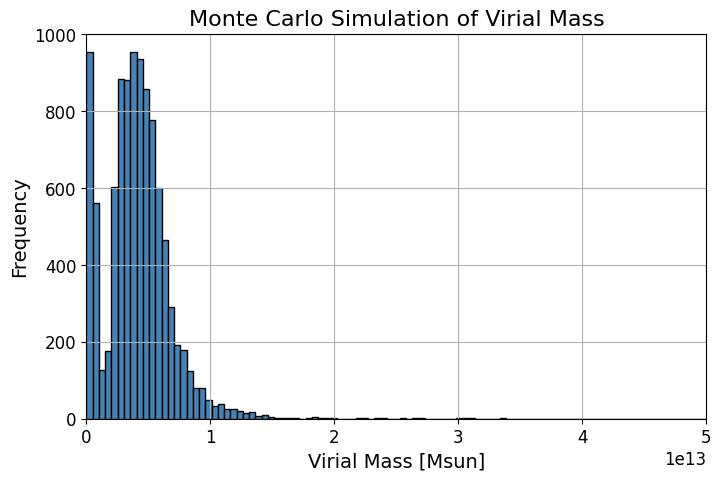

In [21]:
masses = virial_mass_monte_carlo(galaxy_df, velocity="minor_infall_velocity", galaxy_excluded=[galaxy1,galaxy2])

Median Virial Mass: 1.84e+13 Msun
Standard Deviation (σ): 1.03e+13 Msun
Median sisgma velocities: 1.66e+02 km/s
Standard Deviation (σ): 2.98e+01 km/s
Median Virial Mass: 1.84e+13 Msun
Asymmetric Uncertainty: -7.35e+12 / +1.11e+13 Msun


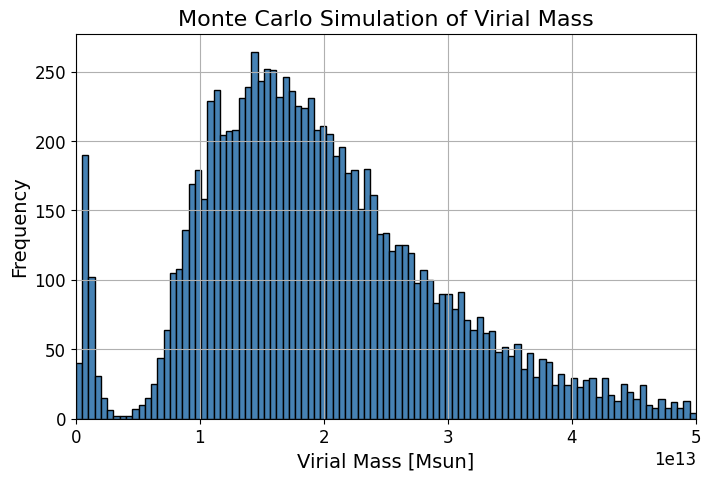

In [22]:
masses = virial_mass_monte_carlo(galaxy_df, velocity="major_infall_velocity", galaxy_excluded=[galaxy1,galaxy2])

In [15]:
def Dist3D(RA1,Dec1,Dist1,RA2,Dec2,Dist2):
    vec1=equatorial_to_cartesian(Dist1,RA1,Dec1)
    vec2=equatorial_to_cartesian(Dist2,RA2,Dec2)
    return np.linalg.norm(vec1-vec2)

def projected_distance(RA_series,Dec_series,Dist_series):
    RA = np.array(RA_series)
    Dec = np.array(Dec_series)
    Dist = np.array(Dist_series)
    if len(RA) != len(Dec):
        raise ValueError("Mismatched array lengths.")
    N=len(RA)
    sum_inversed_projected_distance = 0
    count=0
    for i in range(0,N):
        for j in range(i+1,N):
            Rij = Dist3D(RA[i],Dec[i],Dist[i],RA[j],Dec[j],Dist[j])# np.arccos(np.sin(Dec[i])*np.sin(Dec[j])+np.cos(Dec[i])*np.cos(Dec[j])*np.cos(RA[i]-RA[j]))*Dist
            sum_inversed_projected_distance += 1/Rij
            count +=1
    return count/sum_inversed_projected_distance

def virial_mass_monte_carlo_dis(df, velocity, galaxy_excluded, row_name="CoM_CenA_M83_0.64",
                              velocity_min=-500, velocity_max=500,distance_min=1, distance_max=3,
                              max_velocity_uncertainty=500,
                              N_samples=20000):
 
     
    # Apply the same filtering mask
    vel_col = velocity + "_" + row_name
    dis_col = "dis_center_" + row_name
    e_min_vel_col = "e_" + velocity + "_min_"+row_name
    e_min_dis_col = "e_" + "dis_center_" + "min_"+row_name
    e_max_vel_col = "e_" + velocity + "_max_"+row_name
    e_max_dis_col = "e_" + "dis_center_" + "max_"+row_name




    virial_masses = []
    sigma_velocities=[]
    for K in range(N_samples):
        if K%1000==0:
            print(K)
        dis=np.random.uniform(distance_min,distance_max)
        mask = (
            (galaxy_df['ref_V_h'] == 'LEDA')&
            (~df['Name'].str.startswith('CoM_')) &
            (~df['Name'].isin(galaxy_excluded)) &
            (df[vel_col] >= velocity_min) &
            (df[vel_col] <= velocity_max) &
            (df[dis_col] <= dis) &
            (df[e_min_vel_col] <= max_velocity_uncertainty) &
            (df[e_max_vel_col] <= max_velocity_uncertainty) & 
            (df[e_max_dis_col].notna()) &
            (df[e_max_vel_col].notna()) &
            (df[e_min_dis_col].notna()) &
            (df[e_min_vel_col].notna())
        )

        df_filtered = df[mask].copy()
        RA=df_filtered["RA_radians"]
        Dec=df_filtered["Dec_radians"]
        
        # Randomly sample velocity and distance with Gaussian noise
        sampled_vel = sample_asymmetric_gaussian(
            df_filtered[vel_col].values,
            df_filtered[e_min_vel_col].values,
            df_filtered[e_max_vel_col].values,
            size=len(df_filtered)
        )
        
        sampled_dis = sample_asymmetric_gaussian(
            df_filtered[dis_col].values,
            df_filtered[e_min_dis_col].values,
            df_filtered[e_max_dis_col].values,
            size=len(df_filtered)
        )
        alpha = np.random.uniform(2,5.5)
        # Avoid division by zero or negative distances
        sampled_dis = np.clip(sampled_dis, 1e-3, None)

        # Compute sigma_v and R_g for this sample
        R_g=projected_distance(RA_series=RA,  Dec_series=Dec,  Dist_series= sampled_dis)
        sigma_v = (sampled_vel**2).mean() - sampled_vel.mean()**2
        sigma_velocities.append(sigma_v)
        M_vir = (alpha / G) * sigma_v * R_g
        virial_masses.append(M_vir)
   
    # Plot histogram
   
    # Convert to NumPy array and drop values outside the range
    virial_masses = np.array(virial_masses)
    
    median = np.median(virial_masses)
    sigma = np.std(virial_masses)
   
    print(f"Median Virial Mass: {median:.2e} Msun")
    print(f"Standard Deviation (σ): {sigma:.2e} Msun")
    
    sigma_velocities=np.sqrt(np.array(sigma_velocities))
    median_sigma_velocities = np.median(sigma_velocities)
    lower_sigma_velocities = np.percentile(sigma_velocities,16)
    upper_sigma_velocities = np.percentile(sigma_velocities,84)
    uncertainty_sigma_minus = median_sigma_velocities - lower_sigma_velocities
    uncertainty_sigma_plus = upper_sigma_velocities - median_sigma_velocities
   
    print(f"Median sisgma velocities: {median_sigma_velocities:.3e} km/s")
    print(f"Asymmetric Uncertainty: -{uncertainty_sigma_minus:.3e} / +{uncertainty_sigma_plus:.3e} km/s")
    
    
    lower = np.percentile(virial_masses, 16)
    upper = np.percentile(virial_masses, 84)
    uncertainty_minus = median - lower
    uncertainty_plus = upper - median
    
    print(f"Median Virial Mass: {median:.2e} Msun")
    print(f"Asymmetric Uncertainty: -{uncertainty_minus:.2e} / +{uncertainty_plus:.2e} Msun")
    # Define bin edges linearly spaced from 0 to 1e13
    bins = np.linspace(0, 5e13, 100)
   
    # Plot the histogram
    plt.figure(figsize=(8, 5))
    plt.hist(virial_masses, bins=bins, color='steelblue', edgecolor='k')
    plt.xlabel('Virial Mass [Msun]')
    plt.ylabel('Frequency')
    plt.xlim(0, 5e13)  # Optional: narrower x-axis for better visibility
    plt.title('Monte Carlo Simulation of Virial Mass')
    plt.grid(True)
    plt.show()
   
    return virial_masses

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
Median Virial Mass: 9.68e+12 Msun
Standard Deviation (σ): 7.61e+12 Msun
Median sisgma velocities: 1.731e+02 km/s
Asymmetric Uncertainty: -3.102e+01 / +5.063e+01 km/s
Median Virial Mass: 9.68e+12 Msun
Asymmetric Uncertainty: -4.63e+12 / +7.90e+12 Msun


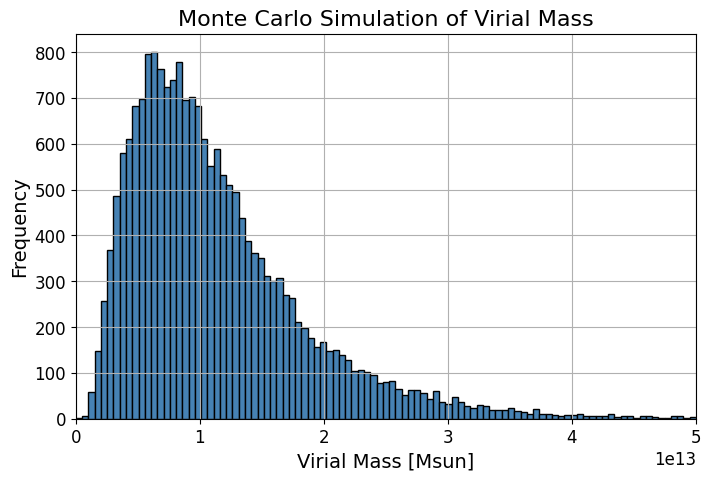

In [16]:
# masses = virial_mass_monte_carlo_dis(galaxy_df, velocity="minor_infall_velocity", galaxy_excluded=[galaxy1,galaxy2])
masses = virial_mass_monte_carlo_dis(galaxy_df, velocity="major_infall_velocity", galaxy_excluded=[galaxy1,galaxy2])

In [ ]:
def virial_mass_monte_carlo_dis_func(df, velocity, galaxy_excluded, row_name="CoM_CenA_M83_0.64",
                              velocity_min=-500, velocity_max=500,distance_min=1, distance_max=3,step=0.1,
                              max_velocity_uncertainty=500,
                              N_samples=10000):
    vel_col = velocity + "_" + row_name
    dis_col = "dis_center_" + row_name
    e_min_vel_col = "e_" + velocity + "_min_"+row_name
    e_min_dis_col = "e_" + "dis_center_" + "min_"+row_name
    e_max_vel_col = "e_" + velocity + "_max_"+row_name
    e_max_dis_col = "e_" + "dis_center_" + "max_"+row_name
    bin_dis = np.linspace(distance_min,distance_max,step)
    
    mean_masses=[]
    std_masses=[]
    for k in bin_dis:

        mask = (
            (~df['Name'].str.startswith('CoM_')) &
            (~df['Name'].isin(galaxy_excluded)) &
            (df[vel_col] >= velocity_min) &
            (df[vel_col] <= velocity_max) &
            (df[dis_col] <= k) &
            (df[e_min_vel_col] <= max_velocity_uncertainty) &
            (df[e_max_vel_col] <= max_velocity_uncertainty) & 
            (df[e_max_dis_col].notna()) &
            (df[e_max_vel_col].notna()) &
            (df[e_min_dis_col].notna()) &
            (df[e_min_vel_col].notna())
        )

        df_filtered = df[mask].copy()
        virial_masses = []
        for _ in range(N_samples):
            dis=np.random.uniform(distance_min,distance_max)
            mask = (
                (~df['Name'].str.startswith('CoM_')) &
                (~df['Name'].isin(galaxy_excluded)) &
                (df[vel_col] >= velocity_min) &
                (df[vel_col] <= velocity_max) &
                (df[dis_col] <= dis) &
                (df[e_min_vel_col] <= max_velocity_uncertainty) &
                (df[e_max_vel_col] <= max_velocity_uncertainty) & 
                (df[e_max_dis_col].notna()) &
                (df[e_max_vel_col].notna()) &
                (df[e_min_dis_col].notna()) &
                (df[e_min_vel_col].notna())
            )

            df_filtered = df[mask].copy()


            # Randomly sample velocity and distance with Gaussian noise
            sampled_vel = sample_asymmetric_gaussian(
                df_filtered[vel_col].values,
                df_filtered[e_min_vel_col].values,
                df_filtered[e_max_vel_col].values,
                size=len(df_filtered)
            )

            sampled_dis = sample_asymmetric_gaussian(
                df_filtered[dis_col].values,
                df_filtered[e_min_dis_col].values,
                df_filtered[e_max_dis_col].values,
                size=len(df_filtered)
            )
            alpha = np.random.uniform(2,5.5)
            # Avoid division by zero or negative distances
            sampled_dis = np.clip(sampled_dis, 1e-3, None)

            # Compute sigma_v and R_g for this sample
    
            sigma_v = (sampled_vel ** 2).mean()
            R_g = 1 / ((1 / sampled_dis).mean())
            M_vir = (alpha / G) * sigma_v * R_g
            virial_masses.append(M_vir)
    
        # Plot histogram
    
        # Convert to NumPy array and drop values outside the range
        virial_masses = np.array(virial_masses)
    
        mean_masses = np.mean(virial_masses)
        sigma = np.std(virial_masses)
   
    print(f"Median Virial Mass: {median:.2e} Msun")
    print(f"Standard Deviation (σ): {sigma:.2e} Msun")
    # Define bin edges linearly spaced from 0 to 1e13
    bins = np.linspace(0, 5e13, 100)
   
    # Plot the histogram
    plt.figure(figsize=(8, 5))
    plt.hist(virial_masses, bins=bins, color='steelblue', edgecolor='k')
    plt.xlabel('Virial Mass [Msun]')
    plt.ylabel('Frequency')
    plt.xlim(0, 5e13)  # Optional: narrower x-axis for better visibility
    plt.title('Monte Carlo Simulation of Virial Mass')
    plt.grid(True)
    plt.show()
   
    return virial_masses